# Exoplanet Classification — Kepler Objects of Interest (KOI)
### India High School Exoplanet Data Challenge · Celesta

**Goal:** predict `koi_disposition` (is a Kepler signal a real planet or a false positive?) from the
transit and stellar features in the NASA KOI cumulative table.


**The plan:** Explore → Clean → Model → Evaluate → Interpret.

In [1]:
# Pull the full dataset straight from the challenge's Google Drive folder
!gdown --folder "https://drive.google.com/drive/folders/1Le5_AkWSzFYEHKtRZkvl5xo9s72OONuX" -O /content/challenge_data --remaining-ok

import glob, shutil
csv_path = glob.glob("/content/challenge_data/**/*.csv", recursive=True)[0]
shutil.copy(csv_path, "KOI_Cumulative_clean.csv")   # overwrite the truncated file

import pandas as pd
print("Loaded from:", csv_path)
print("Shape:", pd.read_csv("KOI_Cumulative_clean.csv").shape, "  <-- want (9564, 140)")

Retrieving folder contents
Processing file 1Vnyg3BcSmICPRPpxcq-Y_4mjMNV796yA Celesta_Dataset_Guide.pdf
Processing file 1l66Rjk-N9KWL9nPWvK_ZtzUO-4-SRcrQ KOI_Cumulative_clean.csv
Retrieving folder contents completed
Building directory structure
Building directory structure completed
Downloading...
From: https://drive.google.com/uc?id=1Vnyg3BcSmICPRPpxcq-Y_4mjMNV796yA
To: /content/challenge_data/Celesta_Dataset_Guide.pdf
100% 114k/114k [00:00<00:00, 49.1MB/s]
Downloading...
From: https://drive.google.com/uc?id=1l66Rjk-N9KWL9nPWvK_ZtzUO-4-SRcrQ
To: /content/challenge_data/KOI_Cumulative_clean.csv
100% 10.0M/10.0M [00:00<00:00, 24.2MB/s]
Download completed
Loaded from: /content/challenge_data/KOI_Cumulative_clean.csv
Shape: (9564, 140)   <-- want (9564, 140)


## Setup

If a library is missing, install it once from a terminal (or uncomment the pip line below):

```
pip install pandas numpy matplotlib seaborn scikit-learn xgboost
```

In [2]:
from google.colab import data_table
data_table.disable_dataframe_formatter()
# !pip install pandas numpy matplotlib seaborn scikit-learn xgboost

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.ensemble import RandomForestClassifier
from sklearn.impute import SimpleImputer
from sklearn.inspection import permutation_importance
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
                             roc_auc_score, confusion_matrix, roc_curve)

# XGBoost is optional — the notebook still works without it (Random Forest is the fallback).
try:
    import xgboost as xgb
    HAS_XGB = True
except ImportError:
    HAS_XGB = False
    print("xgboost not installed — skipping it. Run `pip install xgboost` to enable.")

RANDOM_STATE = 42
sns.set_style("whitegrid")
print("Setup complete.")

Setup complete.


## Step 1 — Load the data and take a first look

In [3]:
# Adjust the path if your CSV lives somewhere else.
df = pd.read_csv("KOI_Cumulative_clean.csv")

print("Shape:", df.shape)          # expect ~ (9564, 140)
df.head()

Shape: (9564, 140)


,rowid,kepid,kepoi_name,kepler_name,koi_disposition,koi_vet_stat,koi_vet_date,koi_pdisposition,koi_fpflag_nt,koi_fpflag_ss,...,koi_dicco_mdec,koi_dicco_mdec_err,koi_dicco_msky,koi_dicco_msky_err,koi_dikco_mra,koi_dikco_mra_err,koi_dikco_mdec,koi_dikco_mdec_err,koi_dikco_msky,koi_dikco_msky_err
0,1,10797460,K00752.01,Kepler-227 b,CONFIRMED,Done,2018-08-16,CANDIDATE,0,0,...,0.200,0.160,0.200,0.170,0.080,0.130,0.310,0.170,0.320,0.160
1,2,10797460,K00752.02,Kepler-227 c,CONFIRMED,Done,2018-08-16,CANDIDATE,0,0,...,0.000,0.480,0.390,0.360,0.490,0.340,0.120,0.730,0.500,0.450
2,3,10811496,K00753.01,NaN,CANDIDATE,Done,2018-08-16,CANDIDATE,0,0,...,-0.034,0.070,0.042,0.072,0.002,0.071,-0.027,0.074,0.027,0.074
3,4,10848459,K00754.01,NaN,FALSE POSITIVE,Done,2018-08-16,FALSE POSITIVE,0,1,...,0.147,0.078,0.289,0.079,-0.257,0.072,0.099,0.077,0.276,0.076
4,5,10854555,K00755.01,Kepler-664 b,CONFIRMED,Done,2018-08-16,CANDIDATE,0,0,...,-0.090,0.180,0.100,0.140,0.070,0.180,0.020,0.160,0.070,0.200


In [4]:
# The target variable and how balanced the three classes are.
print(df["koi_disposition"].value_counts())
print()
print((df["koi_disposition"].value_counts(normalize=True) * 100).round(1), "%")

koi_disposition
FALSE POSITIVE    4839
CONFIRMED         2747
CANDIDATE         1978
Name: count, dtype: int64

koi_disposition
FALSE POSITIVE    50.6
CONFIRMED         28.7
CANDIDATE         20.7
Name: proportion, dtype: float64 %


## Step 2 — Explore (EDA)


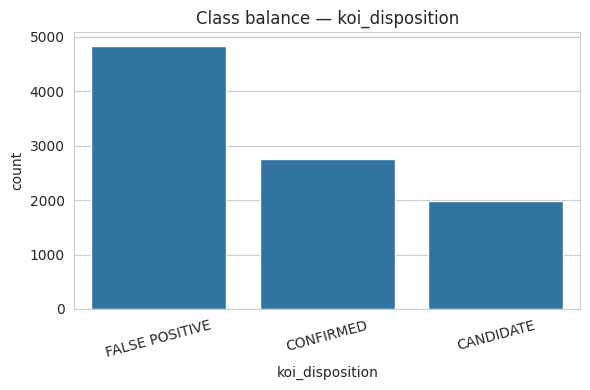

In [5]:
# Class balance
plt.figure(figsize=(6,4))
order = df["koi_disposition"].value_counts().index
sns.countplot(data=df, x="koi_disposition", order=order)
plt.title("Class balance — koi_disposition")
plt.xticks(rotation=15)
plt.tight_layout(); plt.show()

In [6]:
# Missingness: which columns are mostly empty? (top 20)
missing = (df.isna().mean() * 100).sort_values(ascending=False)
missing.head(20).round(1)

,0
koi_sma_err2,100.0
koi_sma_err1,100.0
koi_teq_err1,100.0
koi_teq_err2,100.0
koi_longp_err2,100.0
koi_ingress,100.0
koi_ingress_err2,100.0
koi_ingress_err1,100.0
koi_longp_err1,100.0
koi_longp,100.0


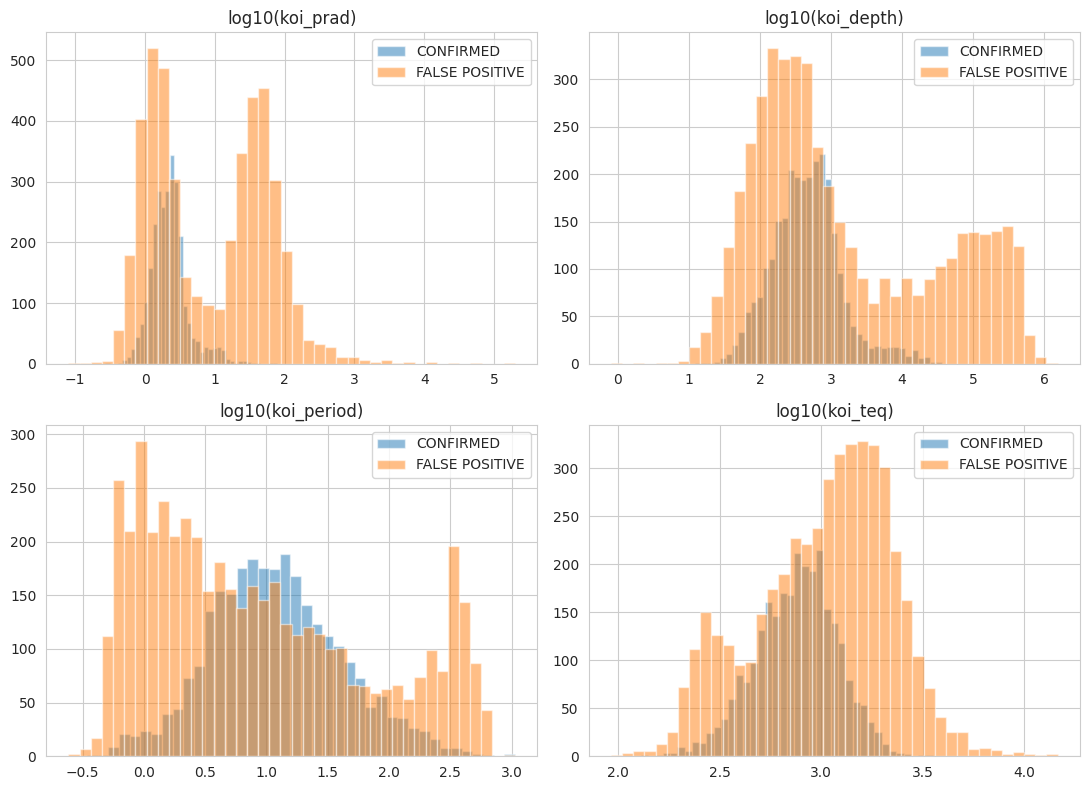

In [7]:
# A few physical features, split by disposition.
# koi_prad = planet radius, koi_depth = transit depth, koi_period = orbital period
features_to_peek = ["koi_prad", "koi_depth", "koi_period", "koi_teq"]

fig, axes = plt.subplots(2, 2, figsize=(11, 8))
for ax, col in zip(axes.ravel(), features_to_peek):
    for label in ["CONFIRMED", "FALSE POSITIVE"]:
        vals = df.loc[df["koi_disposition"] == label, col].dropna()
        # log scale helps because these features span huge ranges
        ax.hist(np.log10(vals[vals > 0]), bins=40, alpha=0.5, label=label)
    ax.set_title(f"log10({col})"); ax.legend()
plt.tight_layout(); plt.show()

The three classes are imbalanced:  The largest share is FALSE POSITIVE (51%) then CONFIRMED (29%) and CANDIDATE (21%). Some columns are almost empty and needed to be worked on while cleaning. None of the physical features (transit depth, orbital period, equilibrium temperature) cleanly separate the classes, with large overlap between confirmed planets and false positives in the feature histograms. The most obvious exception is planet radius (koi_prad): false positives have a clear second population at very large radii--much larger than any real planet--corresponding to eclipsing binary stars masquerading as transits. Confirmed planets are still mostly clustered at small radii. This was a hint from early on that radius was going to be one of the most useful features which the model later confirmed.

## Step 3 — Clean, and remove data leakage ⚠️

This is the most important design decision in the whole project, so read carefully.

**The challenge already removed `koi_score`** because it directly reveals the answer. But several
*other* columns leak the label just as badly — they're outputs of NASA's vetting pipeline, not raw
measurements. If we train on them we'd get ~99% accuracy that means nothing, and a sharp judge would
spot it instantly. So we drop them on purpose:

- `koi_pdisposition` — the pipeline's own disposition (basically a copy of the answer)
- `koi_fpflag_nt / _ss / _co / _ec` — false-positive flags (they encode *why* something was rejected)
- `koi_vet_stat`, `koi_disp_prov`, `koi_comment`, `koi_vet_date` — vetting metadata / human notes

We also drop pure ID columns and the `_err1/_err2` uncertainty columns (noise for classification).

**Class decision:** we model this as a **binary** problem — CONFIRMED vs FALSE POSITIVE — and set the
unresolved CANDIDATE rows aside. We'll come back and score them at the end. (You could instead do a
3-class model; if you try it, explain the trade-off in your report.)

In [8]:
# --- columns that leak the label ---
leak_cols = ["koi_pdisposition", "koi_fpflag_nt", "koi_fpflag_ss", "koi_fpflag_co",
             "koi_fpflag_ec", "koi_vet_stat", "koi_disp_prov", "koi_comment", "koi_vet_date"]

# --- pure identifiers ---
id_cols = ["rowid", "kepid", "kepoi_name", "kepler_name"]

# --- measurement-uncertainty columns ---
err_cols = [c for c in df.columns if c.endswith("_err1") or c.endswith("_err2")]

drop_cols = [c for c in (leak_cols + id_cols + err_cols) if c in df.columns]
print(f"Dropping {len(drop_cols)} columns ({len(leak_cols)} leak, {len(id_cols)} id, {len(err_cols)} error).")

Dropping 59 columns (9 leak, 4 id, 46 error).


In [9]:
# Binary subset: CONFIRMED vs FALSE POSITIVE
binary = df[df["koi_disposition"].isin(["CONFIRMED", "FALSE POSITIVE"])].copy()

# Target: 1 = real planet (CONFIRMED), 0 = FALSE POSITIVE
y = (binary["koi_disposition"] == "CONFIRMED").astype(int)

# Features: drop the leak/id/error columns and the target, keep numeric columns only
X = binary.drop(columns=drop_cols + ["koi_disposition"])
X = X.select_dtypes(include=[np.number])
X = X.dropna(axis=1, how="all")   # remove any columns that are entirely empty

print("Feature matrix:", X.shape, "| positives (CONFIRMED):", int(y.sum()))

# Impute remaining missing values with the median (robust to outliers)
imputer = SimpleImputer(strategy="median")
X_imputed = pd.DataFrame(imputer.fit_transform(X), columns=X.columns, index=X.index)

Feature matrix: (7586, 66) | positives (CONFIRMED): 2747


## Step 4 — Train / test split

Stratified so both classes stay proportional in train and test.

In [10]:
X_train, X_test, y_train, y_test = train_test_split(
    X_imputed, y, test_size=0.2, stratify=y, random_state=RANDOM_STATE)

print("Train:", X_train.shape, " Test:", X_test.shape)

Train: (6068, 66)  Test: (1518, 66)


## Step 5 — Train the models

I trained a Random Forest classifier and an XGBoost classifier. Both also handle imbalanced data through class weighting , which is crucial here since there are more false positives than confirmed planets. For the most part, XGBoost was my main model, mostly due to two reasons: it got the best score on all metrics (accuracy, F1 and ROC-AUC) and gradient boosting generally performs well on structured tabular data like this. Random Forest was a good baseline to make sure the XGBoost results weren’t a fluke, and the two were in close agreement which gave me confidence in the pipeline.

In [11]:
# --- Random Forest ---
rf = RandomForestClassifier(n_estimators=300, class_weight="balanced",
                            random_state=RANDOM_STATE, n_jobs=-1)

# 5-fold cross-validation on the training set (never tune on the test set!)
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
cv_f1 = cross_val_score(rf, X_train, y_train, cv=cv, scoring="f1")
print(f"Random Forest CV F1: {cv_f1.mean():.3f} +/- {cv_f1.std():.3f}")

rf.fit(X_train, y_train)

Random Forest CV F1: 0.958 +/- 0.009


RandomForestClassifier(class_weight='balanced', n_estimators=300, n_jobs=-1,
                       random_state=42)

In [12]:
# --- XGBoost (optional) ---
if HAS_XGB:
    ratio = (y_train == 0).sum() / (y_train == 1).sum()   # handles class imbalance
    xgb_model = xgb.XGBClassifier(
        n_estimators=400, max_depth=5, learning_rate=0.05,
        scale_pos_weight=ratio, eval_metric="logloss", random_state=RANDOM_STATE)
    xgb_model.fit(X_train, y_train)
    print("XGBoost trained.")
else:
    xgb_model = None

XGBoost trained.


## Step 6 — Evaluate

The challenge asks for **Accuracy, Precision, Recall, F1, and a Confusion Matrix.** We add
**ROC-AUC** because it's the honest headline metric for an imbalanced binary problem.

In [13]:
def evaluate(model, name):
    pred = model.predict(X_test)
    proba = model.predict_proba(X_test)[:, 1]
    return {
        "Model": name,
        "Accuracy":  accuracy_score(y_test, pred),
        "Precision": precision_score(y_test, pred),
        "Recall":    recall_score(y_test, pred),
        "F1":        f1_score(y_test, pred),
        "ROC-AUC":   roc_auc_score(y_test, proba),
    }

results = [evaluate(rf, "Random Forest")]
if xgb_model is not None:
    results.append(evaluate(xgb_model, "XGBoost"))

results_df = pd.DataFrame(results).set_index("Model").round(3)
results_df   # <-- this is your summary metrics table for the submission

,Accuracy,Precision,Recall,F1,ROC-AUC
Model,,,,,
Random Forest,0.972,0.969,0.953,0.961,0.994
XGBoost,0.977,0.969,0.967,0.968,0.996


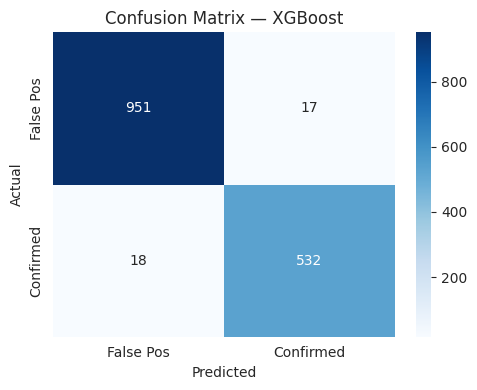

In [14]:
# Confusion matrix for the best model (change `best` if XGBoost wins)
best = xgb_model if xgb_model is not None else rf
best_name = "XGBoost" if xgb_model is not None else "Random Forest"

cm = confusion_matrix(y_test, best.predict(X_test))
plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["False Pos", "Confirmed"],
            yticklabels=["False Pos", "Confirmed"])
plt.title(f"Confusion Matrix — {best_name}")
plt.ylabel("Actual"); plt.xlabel("Predicted")
plt.tight_layout(); plt.show()

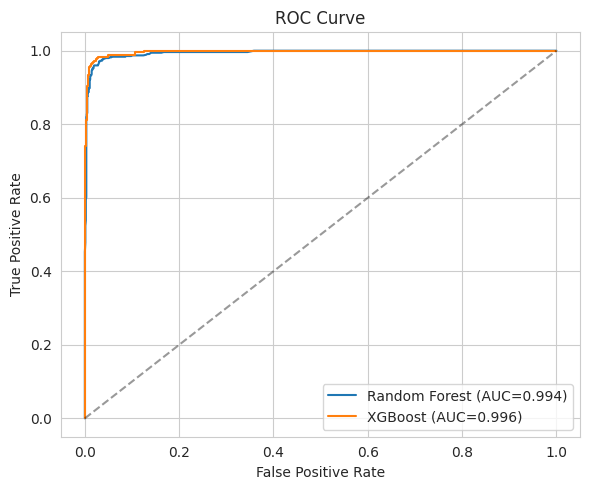

In [15]:
# ROC curves
plt.figure(figsize=(6,5))
for model, name in [(rf, "Random Forest")] + ([(xgb_model, "XGBoost")] if xgb_model else []):
    proba = model.predict_proba(X_test)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, proba)
    plt.plot(fpr, tpr, label=f"{name} (AUC={roc_auc_score(y_test, proba):.3f})")
plt.plot([0,1],[0,1],"k--", alpha=0.4)
plt.xlabel("False Positive Rate"); plt.ylabel("True Positive Rate")
plt.title("ROC Curve"); plt.legend()
plt.tight_layout(); plt.show()

## Step 7 — Interpret: what did the model learn?



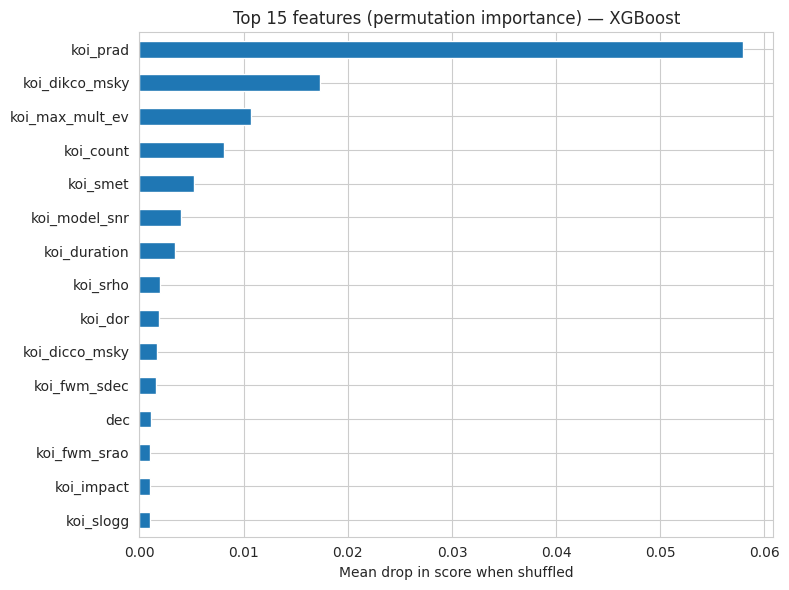

,0
koi_prad,0.0580
koi_dikco_msky,0.0173
koi_max_mult_ev,0.0107
koi_count,0.0082
koi_smet,0.0053
koi_model_snr,0.0040
koi_duration,0.0035
koi_srho,0.0020
koi_dor,0.0019
koi_dicco_msky,0.0017


In [16]:
perm = permutation_importance(best, X_test, y_test, n_repeats=8,
                              random_state=RANDOM_STATE, n_jobs=-1)
importance = (pd.Series(perm.importances_mean, index=X_imputed.columns)
                .sort_values(ascending=False).head(15))

plt.figure(figsize=(8,6))
importance[::-1].plot(kind="barh")
plt.title(f"Top 15 features (permutation importance) — {best_name}")
plt.xlabel("Mean drop in score when shuffled")
plt.tight_layout(); plt.show()

importance.round(4)

The most important feature by far was koi_prad, the estimated planet radius — more than three times more important than anything else. This is physically reasonable: many of the false positives are eclipsing binary stars, where one star passes in front of another blocking a huge amount of light. That makes an "object" many times larger than a planet. So a radius too big to be real is a good sign that the signal isn't a real planet.

The following features are diagnostic rather than physical.koi_dikco_msky checks whether the dimming is really due to the target star, or due to a nearby star slightly off centre – a classic way of catching background eclipsing binaries contaminating the signal. Both koi_max_mult_ev and koi_model_snr are signal quality metrics: real transits are cleanly reproduced with good signal-to-noise, whereas noise-induced false positives are weaker and messier. The model learned to combine one physical check (is this the right size?) with several checks of trustworthiness (is this signal real, and is it coming from the right star?) — which is basically the same logic human astronomers use when vetting Kepler candidates.

## Step 8 — The leakage demonstration 🔍
When the challenge said it removed koi_score to stop the answer from leaking, it made me wonder if other columns leaked it too. Looking at the data dictionary, the false-positive flags (koi_fpflag_*) and koi_pdisposition stood out — they aren't raw telescope measurements, they're the pipeline's own conclusions. To test this, I deliberately retrained a model with those flags added back in, to see how much they inflate the accuracy. If the "leaky" model scores far higher than my honest one, it proves those columns were basically handing the model the answer — which is exactly why removing them matters.

In [17]:
# Rebuild features WITH the leaky false-positive flags included
leaky_flags = ["koi_fpflag_nt", "koi_fpflag_ss", "koi_fpflag_co", "koi_fpflag_ec"]
present_flags = [c for c in leaky_flags if c in binary.columns]

X_leaky = X_imputed.copy()
for c in present_flags:
    X_leaky[c] = pd.to_numeric(binary.loc[X_imputed.index, c], errors="coerce").fillna(0)

Xl_tr, Xl_te, yl_tr, yl_te = train_test_split(
    X_leaky, y, test_size=0.2, stratify=y, random_state=RANDOM_STATE)

leaky_rf = RandomForestClassifier(n_estimators=200, class_weight="balanced",
                                  random_state=RANDOM_STATE, n_jobs=-1).fit(Xl_tr, yl_tr)

print(f"Honest model accuracy (no flags): {accuracy_score(y_test, best.predict(X_test)):.3f}")
print(f"Leaky model accuracy (with flags): {accuracy_score(yl_te, leaky_rf.predict(Xl_te)):.3f}")
print("\nThe leaky model looks better but has learned nothing real — it's reading the pipeline's own verdict.")

Honest model accuracy (no flags): 0.977
Leaky model accuracy (with flags): 0.991

The leaky model looks better but has learned nothing real — it's reading the pipeline's own verdict.


## Step 9 — Score the unresolved CANDIDATEs

Finally, we point our honest model at the ~1,978 CANDIDATE rows NASA hasn't resolved yet, and rank
which ones our model thinks are most likely to be real planets. A nice, memorable way to close.

In [18]:
candidates = df[df["koi_disposition"] == "CANDIDATE"].copy()

# Build the same features for the candidates (align columns, impute with the fitted imputer)
Xc = candidates.reindex(columns=X.columns)
Xc = pd.DataFrame(imputer.transform(Xc), columns=X.columns, index=candidates.index)

candidates["planet_probability"] = best.predict_proba(Xc)[:, 1]

show_cols = [c for c in ["kepoi_name", "kepler_name", "koi_period", "koi_prad", "planet_probability"]
             if c in candidates.columns]
candidates.sort_values("planet_probability", ascending=False)[show_cols].head(10)

,kepoi_name,kepler_name,koi_period,koi_prad,planet_probability
878,K01338.02,NaN,42.037066,1.66,0.999806
3674,K04149.01,NaN,9.546992,1.71,0.999757
1244,K01681.01,NaN,6.939103,1.41,0.999724
7277,K01628.03,NaN,37.840423,1.76,0.999724
5854,K03936.01,NaN,141.608555,2.98,0.999626
1257,K01590.01,NaN,12.890067,1.93,0.999598
1404,K01972.01,NaN,17.791087,2.88,0.999580
5897,K02135.02,NaN,20.189040,1.39,0.999497
1581,K01934.01,NaN,28.782710,2.11,0.999333
4113,K02579.03,NaN,10.301485,1.60,0.999309


## Step 10 — Written Report


**1. Data cleaning and exploratory analysis**

The dataset has 9,564 Kepler Objects of Interest, described by 140 columns. The target koi_disposition is highly imbalanced: false positives are the largest group (51%), followed by confirmed planets (29%) and unresolved candidates (21%). I turned this into a binary problem - confirmed planet vs false positive - and put the candidate rows aside to score at the end, as candidates don't have a confirmed label to learn from.

The most important cleaning step was to eliminate data leakage. The challenge had already released koi_score, but several other columns still reveal the answer because they are outputs of NASA’s own vetting pipeline, rather than raw measurements: koi_pdisposition (the pipeline’s own verdict), the four koi_fpflag columns (false-positive flags), and vetting metadata like koi_vet_stat and koi_comment. I dropped all of them, the ID columns and the measurement-uncertainty (_err) columns, as training on them would result in an artificially high score which does not reflect anything the model actually learned. I dropped 59 columns and any that were completely empty, then filled remaining gaps using the median of each feature, which is robust to the extreme outliers in this data. This resulted in 66 physical and signal quality features.

In terms of features, the majority (transit depth, orbital period, equilibrium temperature) show a large overlap between the two classes. The clear outlier is the planet radius (koi_prad): false positives make up a separate second population at very large radii, much larger than any real planet, while confirmed planets stay small. This was an early sign that radius would be an important feature.

**2. Model choice**

I trained two classifiers: Random Forest as a robust baseline and XGBoost as my main model. Both address class imbalance through weighting (class_weight="balanced" and scale_pos_weight respectively). I used stratified 5-fold cross-validation on the training set so I never tuned on the test data. XGBoost was my primary choice because it scored highest across every metric and because gradient boosting is well suited to structured tabular data. Random Forest agreed closely with it, which gave me confidence the results were stable rather than a fluke.

**3. Key findings**

On the held-out test set, XGBoost achieved 97.7% accuracy, 0.969 precision, 0.967 recall, an F1-score of 0.968, and a ROC-AUC of 0.996. The confusion matrix shows only 35 errors out of 1,518 test objects — 17 false positives wrongly called planets and 18 real planets missed.

Permutation importance showed koi_prad (planet radius) as by far the most influential feature, more than three times any other. This matches the physics: many false positives are eclipsing binary stars, where one star blocks a large fraction of another's light, producing an "object" far too large to be a planet. The next features — koi_dikco_msky (whether the dimming comes from the target star or a nearby source), koi_max_mult_ev, and koi_model_snr (signal strength and quality) — are trustworthiness checks rather than physical properties. The model essentially learned to combine one question of size with several questions of signal reliability, which mirrors how astronomers vet candidates.

To test the leakage issue directly, I retrained with the false-positive flags added back in. Accuracy jumped from about 0.977 to 0.991,, but this "better" model learned nothing real — it was simply copying the pipeline's existing verdict. This confirmed that my honest model, trained only on physical and signal features, is the more meaningful result.

**4. Explaining it simply**

Think about looking at a streetlight at night. Now imagine things are moving in front of it. A small moth flies by. The light gets a little dimmer for a second. This happens slowly and steadily. On the hand a big bird flies by and it blocks a lot of the light all at once. A real planet is like that moth. It blocks a bit of its stars light every time it goes around the star. A false positive is like the bird. It blocks much light or it dims the wrong light. My model figured out how to tell the difference between a planet and a false positive. It does this by looking at how big the thing passing by seems to be. It also checks if the light is really getting dimmer because of the star we are looking at. The model wants to know if the dimming is actually coming from the star we are watching or if it is coming from something. This helps the model tell the difference between a planet and a false positive, like the big bird.